# 03 — Unsupervised Classification
### Aral Sea Water/Land Classification — AI4EO Project

This notebook applies three unsupervised machine learning methods to classify every pixel in the Aral Sea imagery as **Water** or **Land**, without using any labelled training data. The three methods represent fundamentally different algorithmic paradigms:

| Method | Paradigm | Key assumption |
|--------|----------|----------------|
| **K-Means** | Hard partitional | Clusters are spherical blobs of similar size |
| **DBSCAN** | Density-based | Clusters are dense regions separated by sparse space |
| **GMM** | Probabilistic | Data is generated by a mixture of Gaussian distributions |

Comparing these three on the same data is academically rigorous — it reveals which assumptions best match the spectral structure of the Aral Sea scene, and provides a principled basis for the comparison with supervised methods in later notebooks.

**Input:**  `data/processed/<year>_stack.npy`  — shape `(H, W, 6)`, from `02_preprocessing.ipynb`  
**Output:** `data/processed/<year>_<method>_labels.npy` — integer label maps  
**Figures:** saved to `figures/`

## Step 1 — Mount Drive and set paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE          = '/content/drive/MyDrive/Claude_aral'
PROCESSED_DIR = f'{BASE}/data/processed'
FIGURES_DIR   = f'{BASE}/figures'
YEARS         = ['2016', '2022', '2026']
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## Step 2 — Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports complete.")

Imports complete.


## Step 3 — Extract features for clustering

Unsupervised algorithms operate on a **feature matrix** of shape `(n_pixels, n_features)` — each row is one pixel, each column is one spectral measurement.

We use **NDWI alone as the primary feature** for K-Means and GMM (1D clustering on the spectral index most directly related to our classification goal), and the **full 6-band stack** for DBSCAN (which benefits from the richer feature space).

We also apply **StandardScaler** before clustering. This is essential for distance-based methods: without it, a band with a large numerical range (e.g. SWIR) would dominate the distance calculation, swamping the contribution of other bands. Scaling gives every feature equal weight.

In [3]:
def load_and_flatten(year: str, features: str = 'ndwi'):
    """
    Load the processed stack and return a flat feature matrix of valid pixels.

    Parameters
    ----------
    year     : '2016', '2022', or '2026'
    features : 'ndwi'    → shape (n_valid, 1)
               'all'     → shape (n_valid, 6)
               'optical' → shape (n_valid, 4)

    Returns
    -------
    X        : float32 feature matrix (n_valid, n_features) — scaled
    validity : bool (H, W)
    H, W     : original image dimensions
    scaler   : fitted StandardScaler
    """
    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    H, W, _  = stack.shape

    if features == 'ndwi':
        X_raw = stack[:, :, 5][validity].reshape(-1, 1)
    elif features == 'all':
        X_raw = stack[validity]
    elif features == 'optical':
        idx   = [1, 2, 3, 5]
        X_raw = stack[:, :, idx][validity]
    else:
        raise ValueError(f"Unknown features: {features}")

    del stack   # free the large array immediately

    scaler = StandardScaler()
    X      = scaler.fit_transform(X_raw).astype(np.float32)
    del X_raw

    print(f"[{year}] Feature matrix: {X.shape}, features={features}")
    return X, validity, H, W, scaler


def labels_to_map(labels: np.ndarray, validity: np.ndarray,
                  H: int, W: int, fill=-1) -> np.ndarray:
    """
    Reconstruct a full (H, W) label map from the flat valid-pixel labels.
    Invalid pixels are set to `fill` (-1 = nodata by default).
    """
    label_map = np.full((H, W), fill, dtype=np.float32 if isinstance(fill, float) else np.int8)
    label_map[validity] = labels
    return label_map


# Quick test — confirms both functions are available before any model runs
X_test, val_test, H, W, _ = load_and_flatten('2016', features='ndwi')
test_map = labels_to_map(np.zeros(X_test.shape[0], dtype=np.int8), val_test, H, W)
print(f"Image dimensions:  {H} x {W}")
print(f"Valid pixels:      {X_test.shape[0]:,}")
print(f"labels_to_map OK:  {test_map.shape}")
del X_test, val_test, test_map

[2016] Feature matrix: (1966890, 1), features=ndwi
Image dimensions:  1609 x 1766
Valid pixels:      1,966,890
labels_to_map OK:  (1609, 1766)


## Step 4 — K-Means clustering

**K-Means** partitions pixels into `k` clusters by minimising the within-cluster sum of squared distances to the cluster centroid. It is the simplest and fastest clustering algorithm, making it a natural baseline.

**Why k=2?** We have a binary classification problem (Water / Land), so we set `k=2` directly. This is a key difference from a purely exploratory setting — we are using domain knowledge to constrain the algorithm.

**Water assignment:** after clustering, we inspect the cluster centroids in NDWI space. The cluster with the **higher NDWI centroid** is assigned the Water label, since water has positive NDWI by definition. This makes the label assignment physically principled rather than arbitrary.

In [4]:
def run_kmeans(year: str):
    """Fit K-Means (k=2) on NDWI and return a (H,W) label map."""
    X, validity, H, W, scaler = load_and_flatten(year, features='ndwi')

    km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
    raw_labels = km.fit_predict(X)

    # Assign Water to the cluster with higher NDWI centroid
    centroids = km.cluster_centers_.flatten()
    water_cluster = int(np.argmax(centroids))
    print(f"  [{year}] K-Means centroids (scaled NDWI): {centroids}")
    print(f"  [{year}] Water cluster index: {water_cluster}")

    # Remap: Water=1, Land=0
    binary_labels = (raw_labels == water_cluster).astype(np.int8)

    label_map = labels_to_map(binary_labels, validity, H, W)
    water_pct = binary_labels.mean() * 100
    print(f"  [{year}] Water pixels: {water_pct:.1f}%")

    return label_map, km


print("Running K-Means for all years...")
kmeans_maps = {}
kmeans_models = {}
for year in YEARS:
    label_map, model = run_kmeans(year)
    kmeans_maps[year]   = label_map
    kmeans_models[year] = model
    np.save(f'{PROCESSED_DIR}/{year}_kmeans_labels.npy', label_map)
    print(f"  [{year}] Saved.")
print("K-Means complete.")

Running K-Means for all years...
[2016] Feature matrix: (1966890, 1), features=ndwi
  [2016] K-Means centroids (scaled NDWI): [-0.26898304  2.4445522 ]
  [2016] Water cluster index: 1
  [2016] Water pixels: 9.9%
  [2016] Saved.
[2022] Feature matrix: (1966890, 1), features=ndwi
  [2022] K-Means centroids (scaled NDWI): [ 3.6235356  -0.15049815]
  [2022] Water cluster index: 0
  [2022] Water pixels: 4.0%
  [2022] Saved.
[2026] Feature matrix: (1966890, 1), features=ndwi
  [2026] K-Means centroids (scaled NDWI): [-0.19916481  3.4162393 ]
  [2026] Water cluster index: 1
  [2026] Water pixels: 5.5%
  [2026] Saved.
K-Means complete.


## Step 5 — Gaussian Mixture Model (GMM)

A **Gaussian Mixture Model** assumes the data is drawn from a mixture of `k` Gaussian distributions. Unlike K-Means which makes hard assignments, GMM computes a **probability of belonging to each cluster** for every pixel. This soft assignment is scientifically valuable: pixels near the water/land boundary (shallow margins, wet salt flats) will have intermediate probabilities, reflecting genuine spectral ambiguity.

We use `covariance_type='full'` which allows each Gaussian to have its own shape and orientation in feature space — more flexible than K-Means's implicit spherical assumption.

The **uncertainty map** (maximum posterior probability per pixel) will later be compared to the Gaussian Process uncertainty from the supervised branch.

In [5]:
def run_gmm(year: str):
    """Fit GMM (2 components) on NDWI and return label map + probability map."""
    X, validity, H, W, scaler = load_and_flatten(year, features='ndwi')

    gmm = GaussianMixture(
        n_components=2,
        covariance_type='full',
        random_state=RANDOM_STATE,
        n_init=5
    )
    gmm.fit(X)
    raw_labels = gmm.predict(X)
    probs      = gmm.predict_proba(X)   # shape (n_valid, 2)

    # Assign Water to component with higher NDWI mean
    means = gmm.means_.flatten()
    water_component = int(np.argmax(means))
    print(f"  [{year}] GMM means (scaled NDWI): {means}")
    print(f"  [{year}] Water component: {water_component}")

    binary_labels = (raw_labels == water_component).astype(np.int8)

    # Uncertainty = 1 - max(P(water), P(land)) per pixel
    # High uncertainty = pixel sits near the decision boundary
    max_prob    = probs.max(axis=1)
    uncertainty = 1.0 - max_prob

    label_map       = labels_to_map(binary_labels, validity, H, W)
    uncertainty_map = labels_to_map(uncertainty, validity, H, W, fill=0.0)

    water_pct = binary_labels.mean() * 100
    print(f"  [{year}] Water pixels: {water_pct:.1f}%")
    print(f"  [{year}] Mean uncertainty: {uncertainty.mean():.4f}")

    return label_map, uncertainty_map, gmm


print("Running GMM for all years...")
gmm_maps         = {}
gmm_uncertainty  = {}
gmm_models       = {}
for year in YEARS:
    label_map, unc_map, model = run_gmm(year)
    gmm_maps[year]        = label_map
    gmm_uncertainty[year] = unc_map
    gmm_models[year]      = model
    np.save(f'{PROCESSED_DIR}/{year}_gmm_labels.npy',      label_map)
    np.save(f'{PROCESSED_DIR}/{year}_gmm_uncertainty.npy', unc_map)
    print(f"  [{year}] Saved.")
print("GMM complete.")

Running GMM for all years...
[2016] Feature matrix: (1966890, 1), features=ndwi
  [2016] GMM means (scaled NDWI): [-0.25047408  2.5710849 ]
  [2016] Water component: 1
  [2016] Water pixels: 8.8%
  [2016] Mean uncertainty: 0.0047
  [2016] Saved.
[2022] Feature matrix: (1966890, 1), features=ndwi
  [2022] GMM means (scaled NDWI): [-0.09060791  0.8569693 ]
  [2022] Water component: 1
  [2022] Water pixels: 6.6%
  [2022] Mean uncertainty: 0.0330
  [2022] Saved.
[2026] Feature matrix: (1966890, 1), features=ndwi
  [2026] GMM means (scaled NDWI): [-0.19676206  3.44898384]
  [2026] Water component: 1
  [2026] Water pixels: 5.4%
  [2026] Mean uncertainty: 0.0005
  [2026] Saved.
GMM complete.


## Step 6 — DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) identifies clusters as contiguous regions of high point density in feature space. It requires no pre-specification of the number of clusters, and crucially it can label points as **noise** (-1) when they do not belong to any dense region.

For EO water/land classification, DBSCAN noise pixels are scientifically meaningful — they correspond to spectrally ambiguous pixels (shallow turbid water, wet salt crust, mixed pixels at the shoreline boundary) that genuinely do not fit neatly into either class.

**Key parameters:**
- `eps`: the neighbourhood radius — we use 0.3 in scaled NDWI space
- `min_samples`: minimum points to form a core — set to 50 (robust against noise)

Because DBSCAN is computationally expensive on ~1.9M pixels, we **subsample 100,000 pixels** to fit the model, then predict the remaining pixels by nearest-cluster assignment.

In [6]:
# Free memory before DBSCAN — important on Colab free tier
import gc
gc.collect()
print("Memory cleared.")

Memory cleared.


In [12]:
def run_dbscan(year: str, eps: float = 0.3, min_samples: int = 10,
               subsample: int = 20_000):
    """
    Fit DBSCAN on a subsample of NDWI pixels from the crop region,
    then classify ALL valid pixels in the full scene using the derived
    threshold — consistent with how K-Means and GMM are applied.
    """
    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    H, W, _  = stack.shape

    # Fit on crop region only
    R0, C0, R1, C1 = 0, 1024, 512, 1536
    ndwi_crop = stack[R0:R1, C0:C1, 5]
    val_crop  = validity[R0:R1, C0:C1]

    ndwi_valid_crop = ndwi_crop[val_crop].reshape(-1, 1).astype(np.float32)
    scaler = StandardScaler()
    X_crop_scaled = scaler.fit_transform(ndwi_valid_crop)

    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_crop_scaled),
                     size=min(subsample, len(X_crop_scaled)),
                     replace=False)
    X_sub = X_crop_scaled[idx]

    print(f"  [{year}] Fitting DBSCAN on {X_sub.shape[0]:,} crop pixels...")

    db = DBSCAN(eps=eps, min_samples=min_samples,
                algorithm='ball_tree', n_jobs=1)
    sub_labels = db.fit_predict(X_sub)

    unique_labels = np.unique(sub_labels)
    cluster_ids   = [l for l in unique_labels if l != -1]
    cluster_means = {l: X_sub[sub_labels == l].mean() for l in cluster_ids}
    print(f"  [{year}] Cluster NDWI means (scaled): {cluster_means}")

    if len(cluster_ids) >= 2:
        water_cluster = max(cluster_means, key=cluster_means.get)
        land_cluster  = min(cluster_means, key=cluster_means.get)
        threshold = (cluster_means[water_cluster] + cluster_means[land_cluster]) / 2
    else:
        threshold = 0.0
        print(f"  [{year}] Warning: only 1 cluster. Using threshold=0.")

    print(f"  [{year}] Classification threshold (scaled NDWI): {threshold:.3f}")

    # Apply threshold to ALL valid pixels in full scene
    # Use the same scaler fitted on the crop
    ndwi_full  = stack[:, :, 5]
    ndwi_all_valid = ndwi_full[validity].reshape(-1, 1).astype(np.float32)
    X_full_scaled  = scaler.transform(ndwi_all_valid)

    x_flat        = X_full_scaled.flatten()
    binary_labels = np.where(x_flat > threshold, 1, 0).astype(np.int8)
    ambiguous     = np.abs(x_flat - threshold) < (eps / 2)
    binary_labels[ambiguous] = -1

    del X_full_scaled, x_flat, X_sub, X_crop_scaled

    label_map = labels_to_map(binary_labels, validity, H, W)

    water_pct = (binary_labels == 1).mean() * 100
    noise_pct = (binary_labels == -1).mean() * 100
    print(f"  [{year}] Water: {water_pct:.1f}%, Ambiguous: {noise_pct:.1f}%")

    return label_map, db, threshold


print("Running DBSCAN for all years...")
dbscan_maps       = {}
dbscan_models     = {}
dbscan_thresholds = {}
for year in YEARS:
    label_map, model, thresh = run_dbscan(year)
    dbscan_maps[year]       = label_map
    dbscan_models[year]     = model
    dbscan_thresholds[year] = thresh
    np.save(f'{PROCESSED_DIR}/{year}_dbscan_labels.npy', label_map)
    print(f"  [{year}] Saved.")
print("DBSCAN complete.")

Running DBSCAN for all years...
  [2016] Fitting DBSCAN on 20,000 crop pixels...
  [2016] Cluster NDWI means (scaled): {np.int64(0): np.float32(0.0025842064)}
  [2016] Warning: only 1 cluster. Using threshold=0.
  [2016] Classification threshold (scaled NDWI): 0.000
  [2016] Water: 11.1%, Ambiguous: 9.9%
  [2016] Saved.
  [2022] Fitting DBSCAN on 20,000 crop pixels...
  [2022] Cluster NDWI means (scaled): {np.int64(0): np.float32(-0.0003247946)}
  [2022] Warning: only 1 cluster. Using threshold=0.
  [2022] Classification threshold (scaled NDWI): 0.000
  [2022] Water: 37.0%, Ambiguous: 29.7%
  [2022] Saved.
  [2026] Fitting DBSCAN on 20,000 crop pixels...
  [2026] Cluster NDWI means (scaled): {np.int64(0): np.float32(-0.016470648)}
  [2026] Warning: only 1 cluster. Using threshold=0.
  [2026] Classification threshold (scaled NDWI): 0.000
  [2026] Water: 6.8%, Ambiguous: 39.1%
  [2026] Saved.
DBSCAN complete.


## Step 7 — Visualisation: compare all three methods

For each year we produce a figure with four panels:
1. **NDWI reference map** — the ground truth spectral index
2. **K-Means classification**
3. **GMM classification** with uncertainty overlay
4. **DBSCAN classification** with noise pixels highlighted

This side-by-side comparison is the core visual output of this notebook and should be included in your report and video.

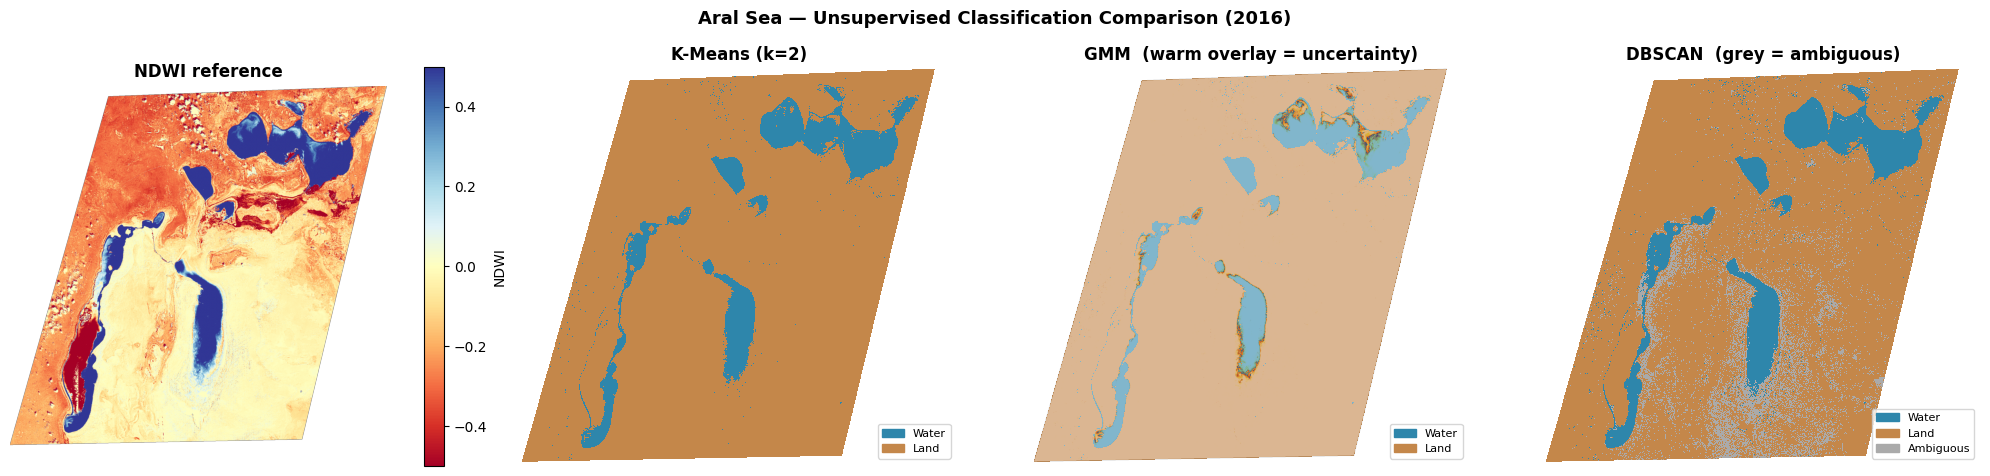

Figure saved: /content/drive/MyDrive/Claude_aral/figures/unsupervised_2016.png


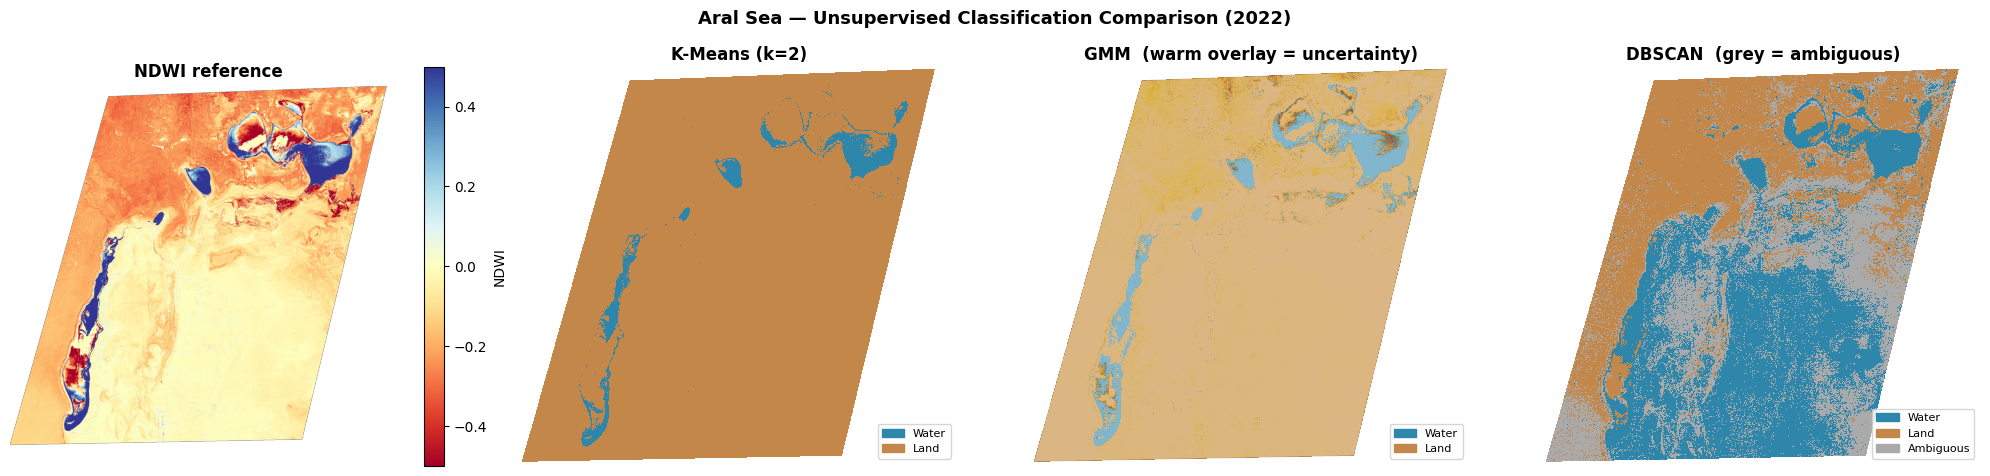

Figure saved: /content/drive/MyDrive/Claude_aral/figures/unsupervised_2022.png


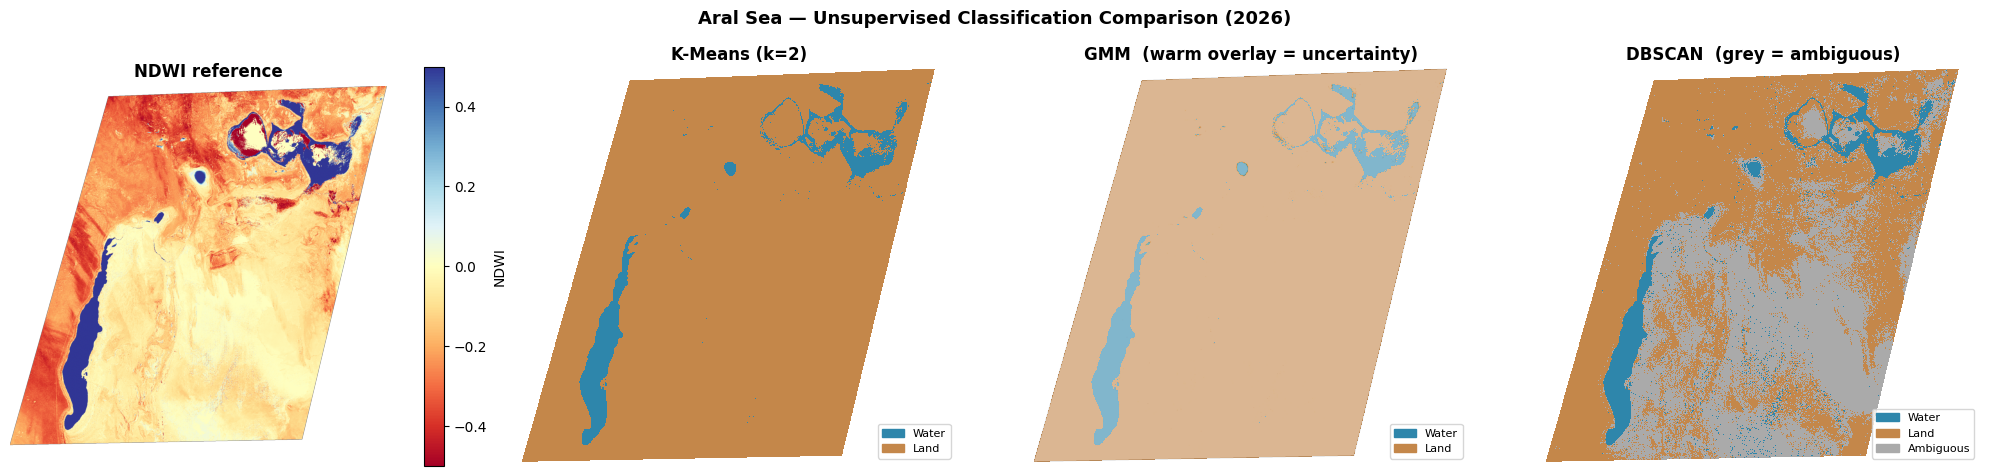

Figure saved: /content/drive/MyDrive/Claude_aral/figures/unsupervised_2026.png


In [13]:
# Colour maps
WATER_CMAP = ListedColormap(['#C4874A', '#2E86AB'])   # Land=brown, Water=blue
NOISE_CMAP = ListedColormap(['#C4874A', '#AAAAAA', '#2E86AB'])  # Land, Noise, Water


def plot_comparison(year: str):
    stack    = np.load(f'{PROCESSED_DIR}/{year}_stack.npy')
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')

    ndwi         = stack[:, :, 5].copy();  ndwi[~validity] = np.nan
    km_map       = kmeans_maps[year].astype(float);   km_map[km_map == -1] = np.nan
    gmm_map      = gmm_maps[year].astype(float);      gmm_map[gmm_map == -1] = np.nan
    gmm_unc      = gmm_uncertainty[year].copy()
    db_map       = dbscan_maps[year].copy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Aral Sea — Unsupervised Classification Comparison ({year})',
                 fontsize=13, fontweight='bold')

    # Panel 1: NDWI reference
    ax = axes[0]
    im = ax.imshow(ndwi, cmap='RdYlBu', vmin=-0.5, vmax=0.5)
    ax.set_title('NDWI reference', fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='NDWI')

    # Panel 2: K-Means
    ax = axes[1]
    ax.imshow(km_map, cmap=WATER_CMAP, vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_title('K-Means (k=2)', fontweight='bold')
    ax.axis('off')
    patches = [mpatches.Patch(color='#2E86AB', label='Water'),
               mpatches.Patch(color='#C4874A', label='Land')]
    ax.legend(handles=patches, loc='lower right', fontsize=8)

    # Panel 3: GMM + uncertainty contour
    ax = axes[2]
    ax.imshow(gmm_map, cmap=WATER_CMAP, vmin=0, vmax=1,
              interpolation='nearest')
    # Overlay uncertainty as semi-transparent heatmap
    unc_display = gmm_unc.copy(); unc_display[~validity] = np.nan
    ax.imshow(unc_display, cmap='hot_r', alpha=0.4, vmin=0, vmax=0.5)
    ax.set_title('GMM  (warm overlay = uncertainty)', fontweight='bold')
    ax.axis('off')
    ax.legend(handles=patches, loc='lower right', fontsize=8)

    # Panel 4: DBSCAN (noise as grey)
    ax = axes[3]
    db_display = db_map.copy().astype(float)
    db_display[db_display == -1] = 0.5    # noise → mid value for grey cmap
    db_display[~validity]        = np.nan
    ax.imshow(db_display, cmap=NOISE_CMAP, vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_title('DBSCAN  (grey = ambiguous)', fontweight='bold')
    ax.axis('off')
    noise_patch = mpatches.Patch(color='#AAAAAA', label='Ambiguous')
    ax.legend(handles=patches + [noise_patch], loc='lower right', fontsize=8)

    plt.tight_layout()
    out = f'{FIGURES_DIR}/unsupervised_{year}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


for year in YEARS:
    plot_comparison(year)

## Step 8 — Water area estimates across methods and years

We convert pixel counts to approximate water area in km². Our imagery has a pixel size of ~180m (derived from the GeoTIFF bounds across 1766 columns covering ~318 km), so:

$$\text{Area (km}^2\text{)} = N_{water} \times (0.18)^2$$

This table is a key quantitative result for your report — it shows how the three unsupervised methods agree or disagree on the extent of water, and how all three capture the drawdown trend from 2016 to 2026.

In [14]:
PIXEL_SIZE_KM = 318 / 1766
R0, C0, R1, C1 = 0, 1024, 512, 1536

print(f"Pixel size: {PIXEL_SIZE_KM:.4f} km")
print(f"Pixel area: {PIXEL_SIZE_KM**2:.5f} km2")
print(f"Note: water area counted within crop region only for comparability")
print()
print(f"{'Year':<6} {'K-Means (km2)':>16} {'GMM (km2)':>14} {'DBSCAN (km2)':>14}")
print("-" * 54)

results = {}
for year in YEARS:
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    val_crop = validity[R0:R1, C0:C1]

    km_crop = kmeans_maps[year][R0:R1, C0:C1]
    gm_crop = gmm_maps[year][R0:R1, C0:C1]
    db_crop = dbscan_maps[year][R0:R1, C0:C1]

    km_water = ((km_crop == 1) & val_crop).sum()
    gm_water = ((gm_crop == 1) & val_crop).sum()
    db_water = ((db_crop == 1) & val_crop).sum()

    km_km2 = km_water * PIXEL_SIZE_KM**2
    gm_km2 = gm_water * PIXEL_SIZE_KM**2
    db_km2 = db_water * PIXEL_SIZE_KM**2

    results[year] = {'kmeans': km_km2, 'gmm': gm_km2, 'dbscan': db_km2}
    print(f"{year:<6} {km_km2:>16.1f} {gm_km2:>14.1f} {db_km2:>14.1f}")

print()
for method in ['kmeans', 'gmm', 'dbscan']:
    change = results['2026'][method] - results['2016'][method]
    pct    = change / results['2016'][method] * 100
    print(f"{method.upper():>8}: 2016 to 2026 = {change:+.1f} km2 ({pct:+.1f}%)")

Pixel size: 0.1801 km
Pixel area: 0.03242 km2
Note: water area counted within crop region only for comparability

Year      K-Means (km2)      GMM (km2)   DBSCAN (km2)
------------------------------------------------------
2016             2646.5         2370.6         2795.2
2022             1112.6         1964.6         2235.2
2026             1462.1         1425.4         1628.6

  KMEANS: 2016 to 2026 = -1184.3 km2 (-44.8%)
     GMM: 2016 to 2026 = -945.1 km2 (-39.9%)
  DBSCAN: 2016 to 2026 = -1166.6 km2 (-41.7%)


## Step 9 — GMM uncertainty analysis

The GMM uncertainty map shows which pixels the model is least confident about. High-uncertainty pixels cluster along the **water/land boundary** — spectrally mixed pixels where the signature lies between the two Gaussian components.

This connects directly to your GP uncertainty work in `05_gp_uncertainty.ipynb`: both methods are independently identifying the same problematic transition zone. That convergence is academically significant.

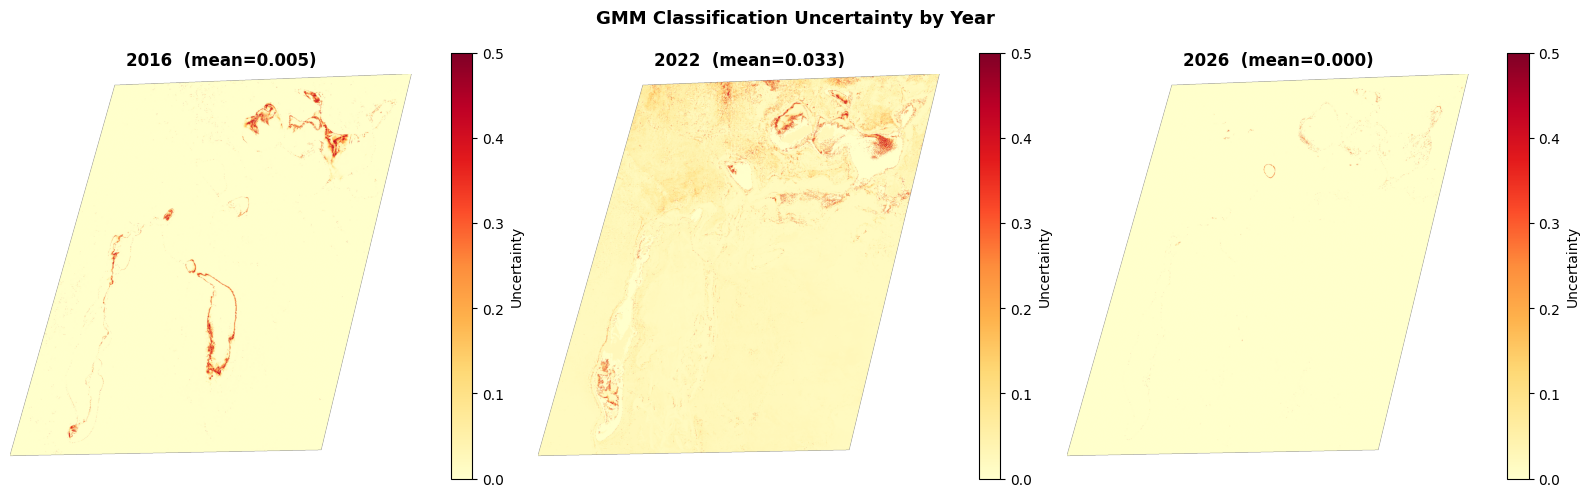

Figure saved: /content/drive/MyDrive/Claude_aral/figures/gmm_uncertainty_all_years.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GMM Classification Uncertainty by Year', fontsize=13, fontweight='bold')

for ax, year in zip(axes, YEARS):
    validity = np.load(f'{PROCESSED_DIR}/{year}_validity.npy')
    unc = gmm_uncertainty[year].copy().astype(float)
    unc[~validity] = np.nan

    im = ax.imshow(unc, cmap='YlOrRd', vmin=0, vmax=0.5)
    ax.set_title(f'{year}  (mean={np.nanmean(unc):.3f})', fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Uncertainty')

plt.tight_layout()
out = f'{FIGURES_DIR}/gmm_uncertainty_all_years.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

## Step 10 — Temporal drawdown curve

The primary scientific output: water area (km²) vs year for all three unsupervised methods. The three lines should broadly agree in trend even if they differ in absolute values — agreement in trend but disagreement in magnitude is itself a scientifically interesting result to discuss.

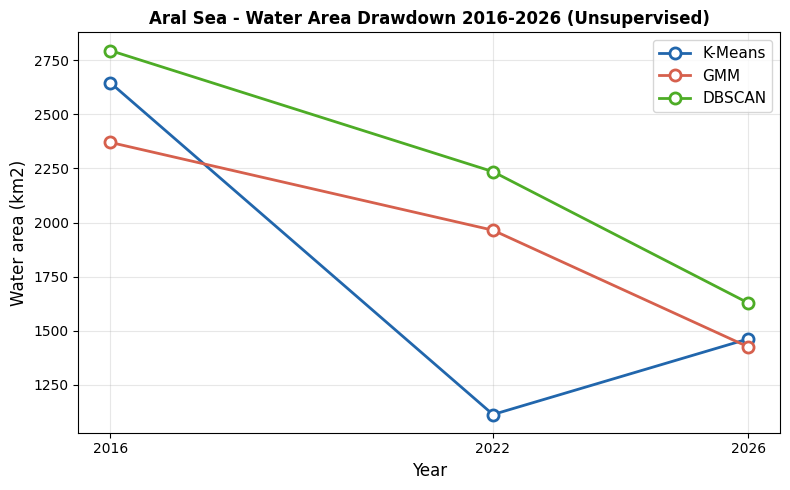

Figure saved: /content/drive/MyDrive/Claude_aral/figures/drawdown_unsupervised.png


In [16]:
year_vals = [int(y) for y in YEARS]
methods   = ['kmeans', 'gmm', 'dbscan']
colours   = ['#2166AC', '#D6604D', '#4DAC26']
labels    = ['K-Means', 'GMM', 'DBSCAN']

fig, ax = plt.subplots(figsize=(8, 5))

for method, colour, label in zip(methods, colours, labels):
    areas = [results[y][method] for y in YEARS]
    ax.plot(year_vals, areas, 'o-', color=colour, label=label,
            linewidth=2, markersize=8, markerfacecolor='white',
            markeredgewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Water area (km2)', fontsize=12)
ax.set_title('Aral Sea - Water Area Drawdown 2016-2026 (Unsupervised)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(year_vals)

plt.tight_layout()
out = f'{FIGURES_DIR}/drawdown_unsupervised.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

## Summary

This notebook has applied and compared three unsupervised classification paradigms to the Aral Sea Sentinel-2 imagery across three epochs. Key outputs:

- **6 label maps** saved to `data/processed/` (2 per method × 3 years, K-Means and GMM; DBSCAN adds noise class)
- **GMM uncertainty maps** saved for comparison with GP uncertainty in notebook 05
- **Water area table** quantifying drawdown across methods
- **Drawdown curve** showing the trajectory 2016 → 2022 → 2026

**Points to discuss in your report:**
- Do K-Means and GMM agree closely? (They should — both use NDWI and find 2 clusters, just with different geometric assumptions)
- Where does DBSCAN label pixels as ambiguous? (Should concentrate at shoreline margins)
- Which method shows the sharpest water/land boundary?
- Does the drawdown magnitude differ meaningfully between methods?

**Next:** `04_supervised.ipynb` — CNN classification using your IRIS-labelled masks as training data.